Implement FireGNN on composite-patient-embeddings 

In [1]:
from tqdm import trange
import sys
import os
import pandas as pd
import torch
import numpy as np
import networkx as nx
import torch
import torch.nn.functional as F


# Add parent directory to path for imports
try:
    base_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    base_dir = os.getcwd()

print(base_dir)
sys.path.append(os.path.dirname(base_dir))
from utils.graph_utils import (
    build_knn_graph_from_features,
    prepare_pytorch_geometric_data,
    get_device,
    set_random_seeds,
    save_graph
)

from fuzzy_models.fuzzy_models import get_fuzzy_model


/Users/yuxiaoxuan/master_thesis/FireGNN/AD


/opt/anaconda3/envs/firegnn/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
design_path = "./data/adni_targets.tsv"
composite_embed_path = './data/composite_embed.pt'

design = pd.read_csv(design_path, sep='\t', index_col=0)
design['Target'] = design['Target'].map({'Control': 0, 'Disease': 1})
labels = design['Target'].to_numpy()

data = torch.load(composite_embed_path)
features = torch.stack([data[idx] for idx in data.keys()]).cpu().tolist()
print('feature dimension: ', (len(features), len(features[0])))

feature dimension:  (744, 64)


In [3]:
# build graph

graph = build_knn_graph_from_features(features, labels, k=16)
print(f'graph is connected: {nx.is_connected(graph)} at 16' )

Building k-NN graph with k=16, metric=cosine


Building initial edges: 100%|██████████| 744/744 [00:00<00:00, 85746.22it/s]


Adding label-based edges...


Adding label edges: 100%|██████████| 744/744 [00:01<00:00, 655.49it/s]


Rewiring edges for better homophily...


Rewiring edges: 100%|██████████| 744/744 [00:01<00:00, 490.11it/s]


Rewired 0 edges


Adding edges: 100%|██████████| 5455/5455 [00:00<00:00, 397303.75it/s]

graph is connected: True at 16


In [4]:
# split train, val, test data

# create masks
def create_train_val_test_masks(features, train_ratio=0.8, val_ratio=0.1):
    total_size = len(features)
    train_size, val_size, test_size = train_ratio*total_size, val_ratio* total_size, (1-train_ratio - val_ratio)*total_size

    train_mask = [i < train_size for i in range(total_size)]
    val_mask = [train_size <= i < train_size + val_size for i in range(total_size)]
    test_mask = [i >= train_size + val_size for i in range(total_size)]
    
    return train_mask, val_mask, test_mask

# add masks to nodes
train_mask, val_mask, test_mask = create_train_val_test_masks(features)

for i, node in enumerate(graph.nodes()):
    graph.nodes[node]['train'] = train_mask[i]
    graph.nodes[node]['val'] = val_mask[i]
    graph.nodes[node]['test'] = test_mask[i]
# save graph
save_graph(graph, './data/composite_patient_k16.pkl')

Saved graph to ./data/composite_patient_k16.pkl: 744 nodes, 5455 edges


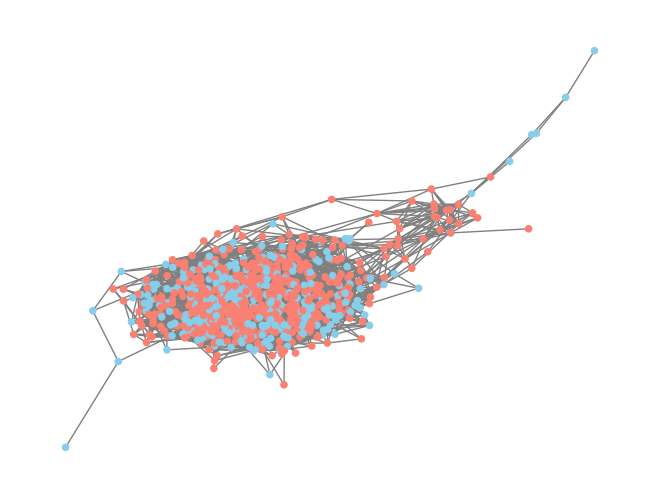

In [5]:
import matplotlib.pyplot as plt

# visulize graph
color_map = {0: 'skyblue', 1: 'salmon'}
node_colors = [color_map[x] for x in labels]
pos = nx.spring_layout(graph)
nx.draw(graph, pos, with_labels=False, node_color= node_colors, edge_color='grey', node_size = 20)
plt.show()

In [6]:
# convert graph to pytorch_geometric_data
Data = prepare_pytorch_geometric_data(graph)
Data

Computing topological features...


Computing two-hop agreement: 100%|██████████| 744/744 [00:00<00:00, 8507.83it/s]


Data(x=[744, 64], edge_index=[2, 10910], edge_attr=[10910], y=[744], train_mask=[744], val_mask=[744], test_mask=[744], topo_features=[744, 6], topo_scaler_mean=[6], topo_scaler_scale=[6])

### Training

In [13]:
@torch.no_grad()
def evaluate(model, data, mask):
    model.eval()
    out, fuzzy_rules = model(
        data.x,
        data.edge_index,
        edge_attr=data.edge_attr,
        topo_features=data.topo_features
    )
    preds = out.argmax(dim=1)
    correct = (preds[mask] == data.y[mask]).sum().item()
    acc = correct / mask.sum().item()
    loss = F.nll_loss(out[mask], data.y[mask]).item()
    return acc, loss, preds, fuzzy_rules


In [14]:
def train(model, data, optimizer, epochs, device):
    history = {
        "train_acc": [],
        "val_acc": [],
        "train_loss": [],
        "val_loss": []
    }

    best_val_acc = 0.0
    best_state = None

    for epoch in trange(epochs, desc="Training"):
        model.train()
        optimizer.zero_grad()

        out, _ = model(
            data.x,
            data.edge_index,
            edge_attr=data.edge_attr,
            topo_features=data.topo_features
        )

        loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask])
        loss.backward()
        optimizer.step()

        # ---- Evaluation ----
        train_acc, train_loss, _, _ = evaluate(model, data, data.train_mask)
        val_acc, val_loss, _, _ = evaluate(model, data, data.val_mask)

        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {k: v.cpu() for k, v in model.state_dict().items()}

    return best_state, history

In [17]:
device = get_device()
in_channels = Data.x.size(1)
hidden_channels = 64
out_channels = int(Data.y.max().item() + 1)

Data.to(device)
# -----------------------------------------------------
# Model
# -----------------------------------------------------
model = get_fuzzy_model(
    model_type='gcn',
    in_channels=in_channels,
    hidden_channels=hidden_channels,
    out_channels=out_channels,
    num_rules=3
).to(device)

optimizer = torch.optim.Adam(
        model.parameters(),
        lr=0.005,
        weight_decay=5e-4
    )


# Train
# -----------------------------------------------------
best_state, history = train(
    model=model,
    data=Data,
    optimizer=optimizer,
    epochs=100,
    device=device
)

print('\ntraining history')
for k,v in history.items():
    print(k,v)
# Load best model
model.load_state_dict(best_state)

# -----------------------------------------------------
# Final evaluation
# -----------------------------------------------------
test_acc, test_loss, test_preds, fuzzy_rules = evaluate(
    model, Data, Data.test_mask
)

print(f"\nTest Accuracy: {test_acc:.4f}")


Training: 100%|██████████| 100/100 [00:01<00:00, 66.17it/s]


training history
train_acc [0.6526845637583892, 0.6526845637583892, 0.6526845637583892, 0.6526845637583892, 0.6526845637583892, 0.6526845637583892, 0.6526845637583892, 0.6526845637583892, 0.6526845637583892, 0.6526845637583892, 0.6526845637583892, 0.6526845637583892, 0.6526845637583892, 0.6526845637583892, 0.6526845637583892, 0.6526845637583892, 0.6526845637583892, 0.6526845637583892, 0.6526845637583892, 0.6526845637583892, 0.6526845637583892, 0.6526845637583892, 0.6526845637583892, 0.6526845637583892, 0.6526845637583892, 0.6526845637583892, 0.6526845637583892, 0.6526845637583892, 0.6526845637583892, 0.6526845637583892, 0.6526845637583892, 0.6526845637583892, 0.6543624161073825, 0.6560402684563759, 0.6577181208053692, 0.6577181208053692, 0.6560402684563759, 0.6593959731543624, 0.6644295302013423, 0.6677852348993288, 0.6661073825503355, 0.6644295302013423, 0.674496644295302, 0.7080536912751678, 0.7214765100671141, 0.7114093959731543, 0.7046979865771812, 0.7013422818791947, 0.7231543624